# Chapter 2: Linear Regression -- Predicting Elastic Stress

This notebook walks through the core concepts of **linear regression** using a practical engineering example: predicting the **stress** of a steel specimen from its measured **strain**.

## 1. Imports

We only need **NumPy** for numerical operations and **Matplotlib** for plotting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Render plots inline in the notebook
%matplotlib inline

## 2. Generating Synthetic Stress-Strain Data

### Physical Background

In the **elastic region**, stress ($\sigma$) is proportional to strain ($\varepsilon$) via **Hooke's law**:

$$\sigma = E \cdot \varepsilon$$

where $E$ is the **modulus of elasticity** (Young's modulus). For typical structural steel, $E \approx 210\,\text{GPa} = 210{,}000\,\text{MPa}$.

We generate 10 synthetic measurements in the elastic range (up to ~0.12% strain) and add noise to simulate real experimental scatter.

In [2]:
# ── Physical Parameters ─────────────────────────────────────────────
E_true = 210_000  # Young's modulus in MPa (210 GPa for steel)

# Strain values in the elastic range (as fractions, e.g., 0.0005 = 0.05%)
strain_fraction = np.linspace(0.00005, 0.0012, 10)  # up to 0.12% strain

# Convert to percentages for easier plotting
strain_percent = strain_fraction * 100

# ── Synthetic Noise ─────────────────────────────────────────────────
# Bidirectional noise to simulate real experimental scatter
noise = np.array([15, -20, 15, -20, 30, -35, 30, -40, 25, -30], dtype=float)

# ── Stress Data ────────────────────────────────────────────────────
# Hooke's law + noise: sigma = E * epsilon + noise
stress = E_true * strain_fraction + noise  # in MPa

# Print the dataset
print("Synthetic Stress-Strain Data")
print("=" * 40)
print(f"{'Strain (%)':>12}  {'Stress (MPa)':>14}")
print("-" * 40)
for s_pct, sig in zip(strain_percent, stress):
    print(f"{s_pct:12.4f}  {sig:14.1f}")

Synthetic Stress-Strain Data
  Strain (%)    Stress (MPa)
----------------------------------------
      0.0050            25.5
      0.0178            17.3
      0.0306            79.2
      0.0433            71.0
      0.0561           147.8
      0.0689           109.7
      0.0817           201.5
      0.0944           158.3
      0.1072           250.2
      0.1200           222.0


## 3. Visualizing the Experimental Data

Let's plot the raw data points. The roughly linear trend is visible, but the noise makes it impossible to draw a perfect line through all points.

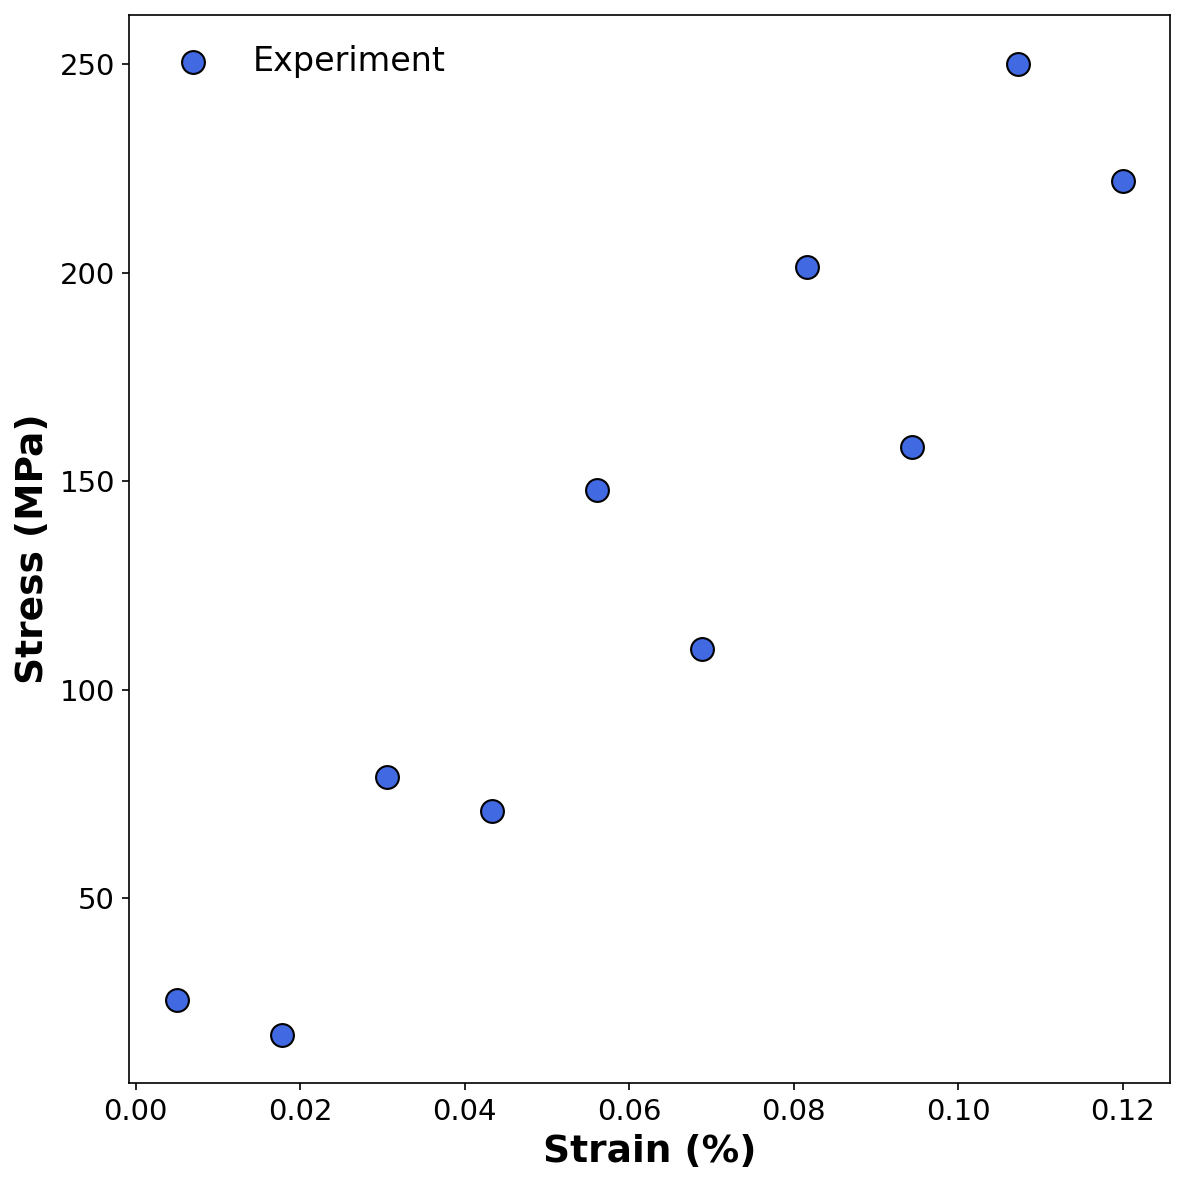

In [3]:
def style_axes(ax, xlabel, ylabel):
    """Helper to apply consistent styling to axes."""
    ax.set_xlabel(xlabel, fontsize=18, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=18, fontweight="bold")
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.grid(False)


fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
ax.scatter(
    strain_percent, stress,
    color="royalblue", edgecolors="black", linewidth=1.0,
    label="Experiment", s=120, zorder=3,
)
style_axes(ax, "Strain (%)", "Stress (MPa)")
legend = ax.legend(fontsize=16)
legend.get_frame().set_edgecolor("none")
fig.tight_layout()
plt.show()

## 4. What Is a "Good" Fit? -- Introducing Residuals

A **residual** is the vertical distance between a data point and a candidate line. If we draw an *arbitrary* line (not fitted), the residuals show how far off each prediction is:

$$\text{residual}_i = y_i - \hat{y}_i$$

The goal of regression is to find the line that makes these residuals as small as possible.

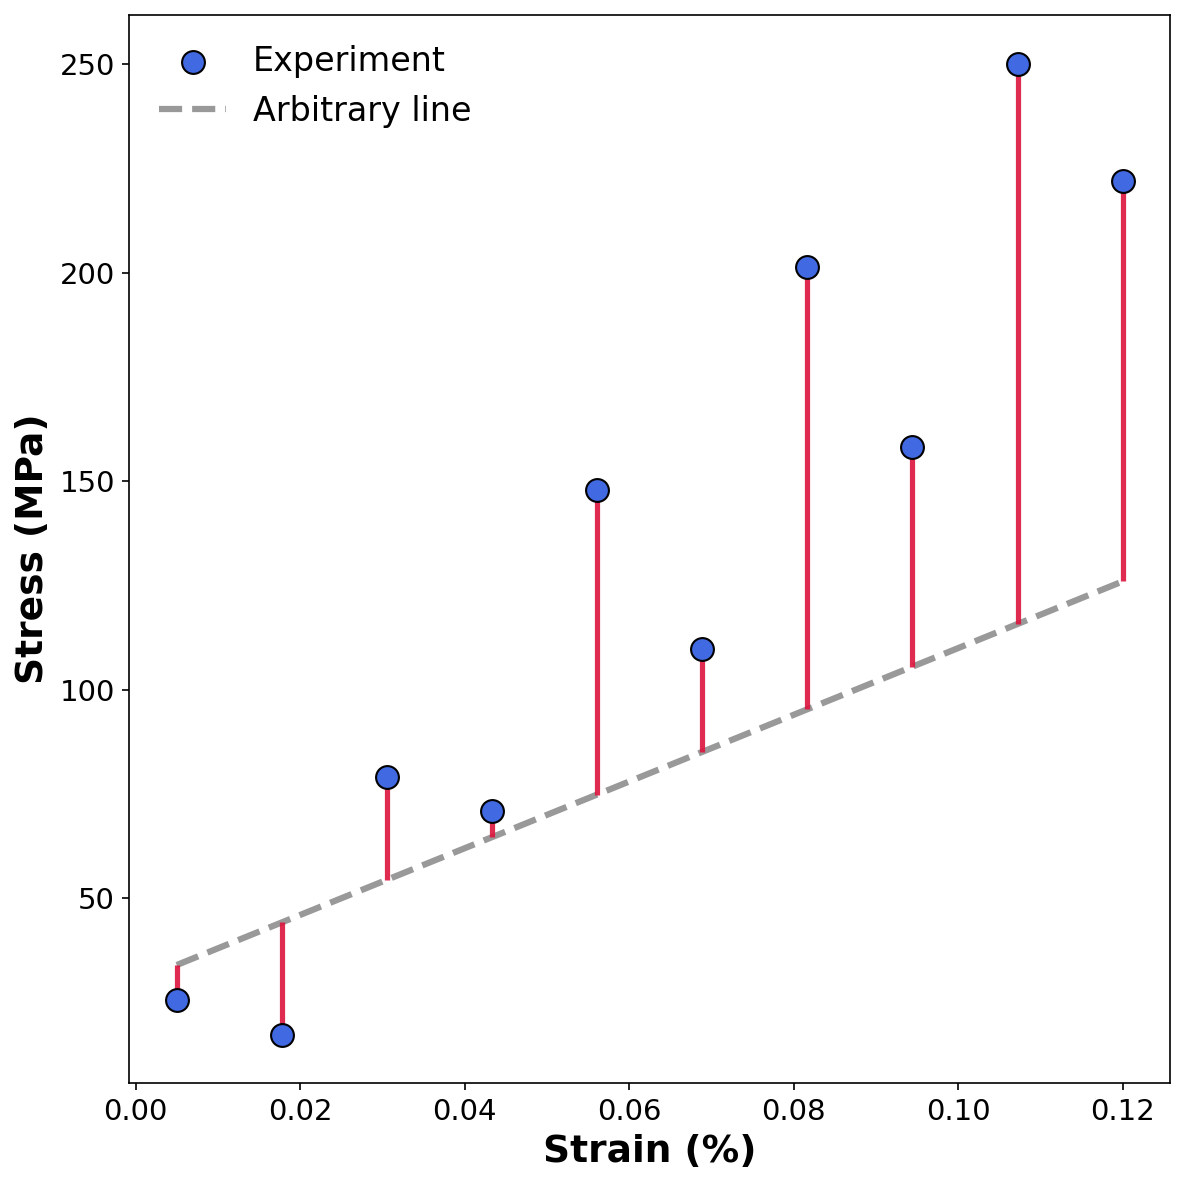

In [25]:
# ── An arbitrary (NOT fitted) line ──────────────────────────────────
arbitrary_slope = 800       # MPa per % strain (intentionally wrong)
arbitrary_intercept = 30    # MPa
stress_guess = arbitrary_slope * strain_percent + arbitrary_intercept

fig, ax = plt.subplots(figsize=(8, 8), dpi=150)

# Data points
ax.scatter(
    strain_percent, stress,
    color="royalblue", edgecolors="black", linewidth=1.0,
    label="Experiment", s=120, zorder=3,
)

# Arbitrary line
ax.plot(
    strain_percent, stress_guess,
    color="gray", linestyle="--", linewidth=3, alpha=0.8,
    label="Arbitrary line", zorder=1,
)

# Draw residuals as red vertical segments
for x_pt, y_data, y_guess in zip(strain_percent, stress, stress_guess):
    ax.vlines(x_pt, y_data, y_guess, colors="crimson", linestyles="-",
              linewidth=2.5, alpha=0.9, zorder=2)

style_axes(ax, "Strain (%)", "Stress (MPa)")
legend = ax.legend(fontsize=16)
legend.get_frame().set_edgecolor("none")
fig.tight_layout()
plt.show()

## 5. The Loss Function: Mean Squared Error (MSE)

To quantify how "bad" a fit is, we define the **Mean Squared Error**:

$$J_{\text{MSE}} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 = \frac{1}{N} \sum_{i=1}^{N} \bigl(y_i - (w_1 x_i + w_0)\bigr)^2$$

where:
- $w_1$ is the **slope** (weight)
- $w_0$ is the **intercept** (bias)
- $N$ is the number of data points

Our goal: find $w_0$ and $w_1$ that **minimize** $J_{\text{MSE}}$.

---

## 6. Gradient Descent

**Gradient descent** is an iterative optimization algorithm. At each step, we:

1. Compute the gradient (partial derivatives) of the loss with respect to each parameter.
2. Update each parameter by moving in the **negative gradient** direction:

$$w_0 \leftarrow w_0 - \eta \cdot \frac{\partial J}{\partial w_0}, \qquad w_1 \leftarrow w_1 - \eta \cdot \frac{\partial J}{\partial w_1}$$

where $\eta$ is the **learning rate** -- a small positive number that controls the step size.

The gradients for MSE are:

$$\frac{\partial J}{\partial w_0} = -\frac{2}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i), \qquad \frac{\partial J}{\partial w_1} = -\frac{2}{N}\sum_{i=1}^{N} x_i(y_i - \hat{y}_i)$$

In [26]:
# ── Gradient Descent Implementation ─────────────────────────────────

# We'll use strain_percent as X and stress as y
X = strain_percent
y = stress


def gd_step(x, y_true, w0, w1):
    """
    Compute one gradient step for MSE loss.
    
    Returns:
        dJ_dw0: partial derivative of J w.r.t. w0 (intercept)
        dJ_dw1: partial derivative of J w.r.t. w1 (slope)
        J:      current MSE loss value
    """
    y_pred = w1 * x + w0          # Predictions: y_hat = w1*x + w0
    error = y_true - y_pred       # Residuals
    n = len(x)
    J = np.mean(error ** 2)       # MSE loss
    dJ_dw0 = (-2.0 / n) * np.sum(error)      # Gradient w.r.t. intercept
    dJ_dw1 = (-2.0 / n) * np.sum(x * error)  # Gradient w.r.t. slope
    return dJ_dw0, dJ_dw1, J


def gradient_descent(x, y_true, lr=0.5, steps=5000, w0_init=0.0, w1_init=50.0):
    """
    Full-batch gradient descent for y = w1*x + w0.
    
    Args:
        x:        input features (strain %)
        y_true:   target values (stress MPa)
        lr:       learning rate (eta)
        steps:    number of iterations
        w0_init:  initial intercept
        w1_init:  initial slope
    
    Returns:
        w0, w1:   fitted parameters
        history:  list of dicts with iteration details
    """
    w0, w1 = float(w0_init), float(w1_init)
    history = []

    # Record iteration 0 (initial state, before any update)
    dJ_dw0, dJ_dw1, J = gd_step(x, y_true, w0=w0, w1=w1)
    history.append({"iter": 0, "w0": w0, "w1": w1, "J": J})

    # Iterative updates
    for k in range(1, steps + 1):
        dJ_dw0, dJ_dw1, _ = gd_step(x, y_true, w0=w0, w1=w1)
        w0 = w0 - lr * dJ_dw0   # Update intercept
        w1 = w1 - lr * dJ_dw1   # Update slope
        _, _, J = gd_step(x, y_true, w0=w0, w1=w1)
        history.append({"iter": k, "w0": w0, "w1": w1, "J": J})

    return w0, w1, history


print("Gradient descent functions defined.")

Gradient descent functions defined.


### 6.1 Running Gradient Descent

We start with an initial guess of $w_0 = 0$ and $w_1 = 50$, and run for 5,000 iterations with learning rate $\eta = 0.5$.

In [29]:
# ── Run gradient descent ────────────────────────────────────────────
w0_gd, w1_gd, gd_history = gradient_descent(
    X, y, lr=0.5, steps=5000, w0_init=0.0, w1_init=50.0
)

# Extract loss values for later plotting
loss_history = [h["J"] for h in gd_history]

print(f"Gradient Descent Result (after 5000 iterations):")
print(f"  w0 (intercept) = {w0_gd:.2f} MPa")
print(f"  w1 (slope)     = {w1_gd:.1f} MPa per % strain")
print(f"  Final MSE      = {loss_history[-1]:.2f}")

Gradient Descent Result (after 5000 iterations):
  w0 (intercept) = 5.45 MPa
  w1 (slope)     = 1964.9 MPa per % strain
  Final MSE      = 707.25


## 7. Closed-Form (Analytical) Solution

For simple linear regression, there is a **closed-form** solution (no iteration needed). Using the normal equations:

$$w_1 = \frac{\sum_{i}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i}(x_i - \bar{x})^2}, \qquad w_0 = \bar{y} - w_1 \bar{x}$$

This gives the exact minimum of the MSE in one step. Let's compare it with our gradient descent result.

In [30]:
# ── Closed-form solution ────────────────────────────────────────────
X_centered = X - np.mean(X)    # Center the features
y_centered = y - np.mean(y)    # Center the targets

w1_closed = np.sum(X_centered * y_centered) / np.sum(X_centered ** 2)
w0_closed = np.mean(y) - w1_closed * np.mean(X)

print(f"Closed-Form Solution:")
print(f"  w0 (intercept) = {w0_closed:.2f} MPa")
print(f"  w1 (slope)     = {w1_closed:.1f} MPa per % strain")
print()
print(f"Gradient Descent Solution:")
print(f"  w0 (intercept) = {w0_gd:.2f} MPa")
print(f"  w1 (slope)     = {w1_gd:.1f} MPa per % strain")
print()


# Difference in calculated parameters (gradient descent vs. closed-form)
dw0 = w0_gd - w0_closed
dw1 = w1_gd - w1_closed

# Relative error w.r.t. the closed-form solution (treat closed-form as the reference)
# We use max(|w_closed|, eps) to avoid division-by-zero in pathological cases.
rtol = 1e-1   # 10% relative tolerance
eps  = 1e-12  # small number to avoid divide-by-zero

rel_err_w0 = abs(dw0) / max(abs(w0_closed), eps)
rel_err_w1 = abs(dw1) / max(abs(w1_closed), eps)

# Check whether both parameters are within 10% of the closed-form solution
close_w0 = rel_err_w0 <= rtol
close_w1 = rel_err_w1 <= rtol

if close_w0 and close_w1:
    print("The gradient descent estimate is within 10% of the closed-form solution, so both methods recover essentially the same fitted line.")
else:
    print("Hmm — gradient descent is not within 10% of the closed-form solution. Try a smaller learning rate, more iterations, or revisit the stopping criterion.")

Closed-Form Solution:
  w0 (intercept) = 5.30 MPa
  w1 (slope)     = 1967.2 MPa per % strain

Gradient Descent Solution:
  w0 (intercept) = 5.45 MPa
  w1 (slope)     = 1964.9 MPa per % strain

The gradient descent estimate is within 10% of the closed-form solution, so both methods recover essentially the same fitted line.


## 8. Best-Fit Line

Now let's plot the best-fit line alongside the data. We use the gradient-descent solution.

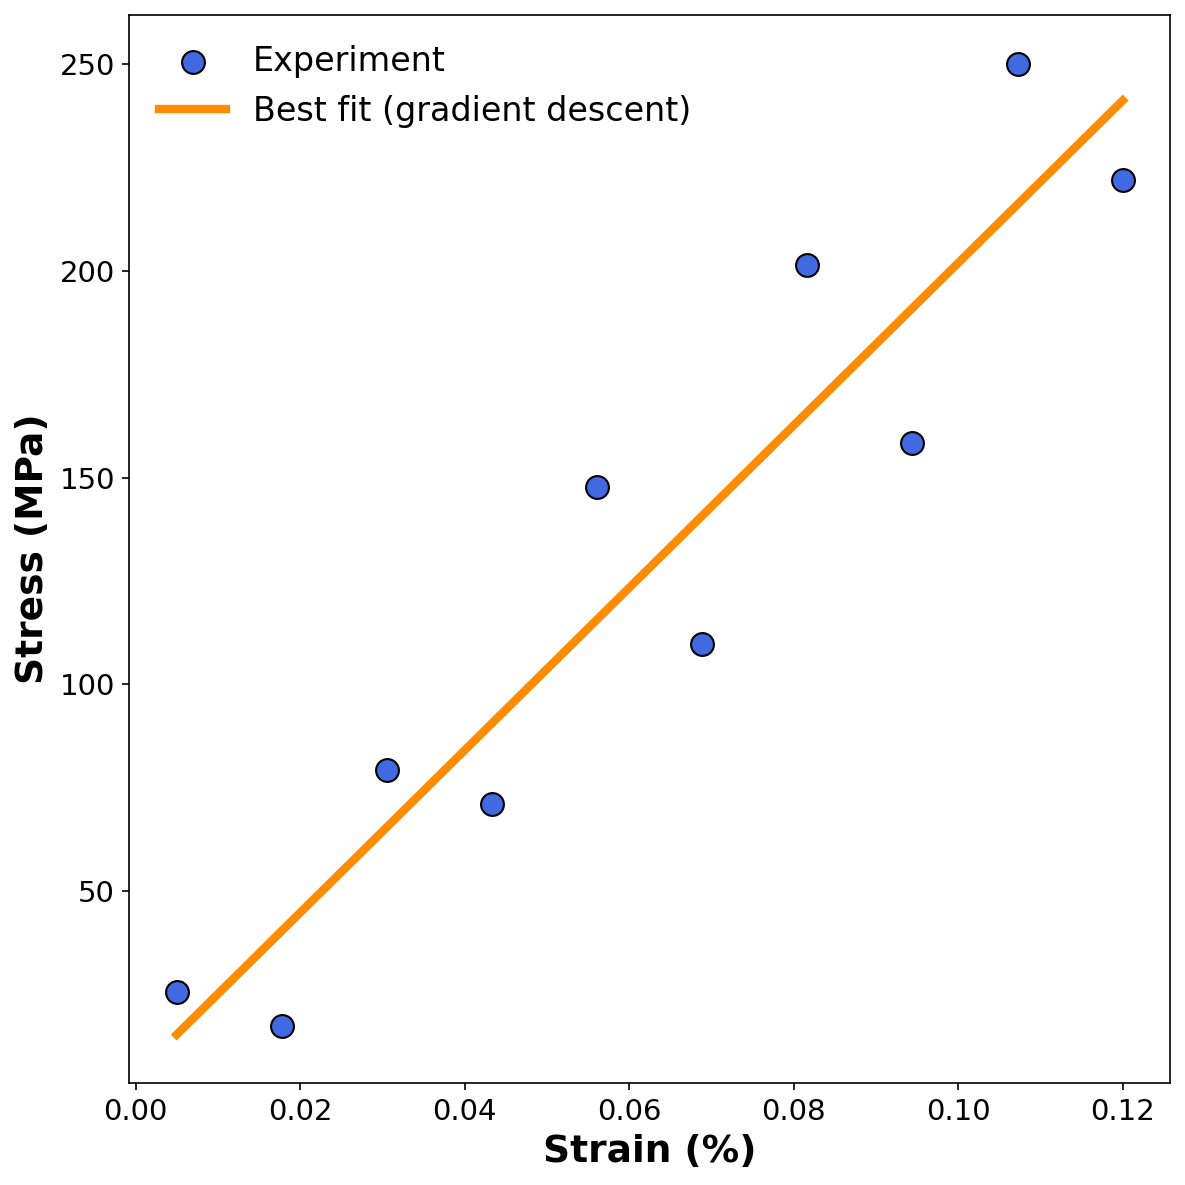

In [31]:
# Compute the best-fit predictions using gradient descent results
y_fit = w1_gd * strain_percent + w0_gd

fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
ax.scatter(
    strain_percent, stress,
    color="royalblue", edgecolors="black", linewidth=1.0,
    label="Experiment", s=120, zorder=3,
)
ax.plot(
    strain_percent, y_fit,
    color="darkorange", linewidth=4,
    label="Best fit (gradient descent)", zorder=2,
)
style_axes(ax, "Strain (%)", "Stress (MPa)")
legend = ax.legend(fontsize=16)
legend.get_frame().set_edgecolor("none")
fig.tight_layout()
plt.show()

## 9. Loss Curve -- Monitoring Convergence

A **loss curve** plots the MSE at each iteration. It lets us verify that gradient descent is converging (the loss should decrease and eventually plateau).

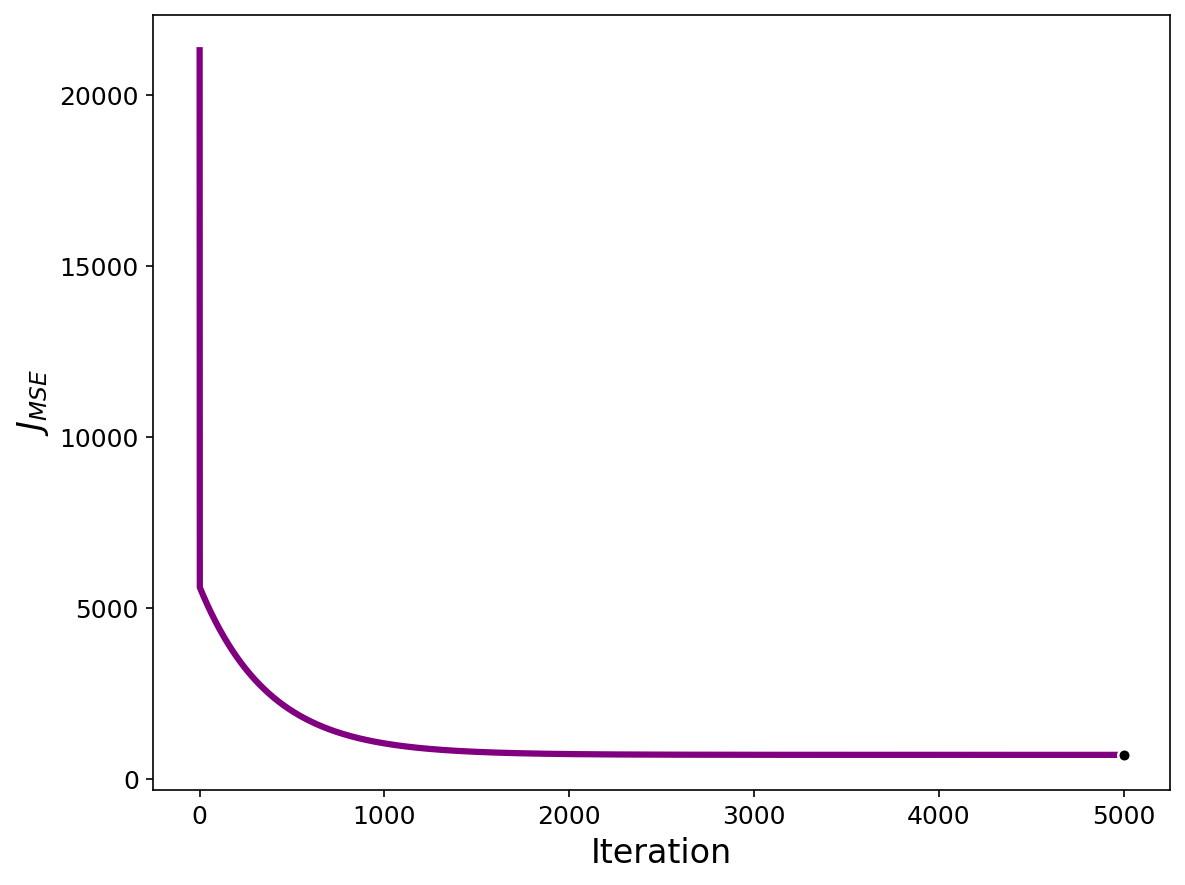

Starting loss (iteration 0): 21314.55
Final loss (iteration 5000): 707.25


In [32]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

ax.plot(
    np.arange(0, len(loss_history)), loss_history,
    color="purple", linewidth=3,
)
# Mark the final converged point
ax.scatter(
    len(loss_history) - 1, loss_history[-1],
    color="black", edgecolors="white", linewidth=1.2, zorder=3,
)

ax.set_xlabel("Iteration", fontsize=16)
ax.set_ylabel(r"$J_{MSE}$", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=12)
ax.grid(False)
fig.tight_layout()
plt.show()

print(f"Starting loss (iteration 0): {loss_history[0]:.2f}")
print(f"Final loss (iteration {len(loss_history)-1}): {loss_history[-1]:.2f}")